<a href="https://colab.research.google.com/github/DeepaJain29/Non-Linear_Regression_Regularization/blob/main/Linear_Regression_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem 1:**

1. Use California Housing Dataset: from sklearn.datasets import fetch_california_housing
x= all features & y=MedHouseVal
2. Perform an 80:20 train/test split, followed by an 80:20 train/validation split from the train set. Perform standard Scaling on all splits. (Use train-test split from sklearn)
3. Perform Linear Regression and Non-Linear Regression using an appropriate Polynomial curve (2,3,5) to reduce error on the Train and Validation Datasets. To prevent Overfitting, use L2 Regularizer with appropriate Lambda values. (Optimize for 100 Epochs)
4. Plot the loss vs epoch curve on different parameters of Polynomial degree and Lambda values on the Train and validation sets to choose appropriate values.
5. Predict on the Test set for any top-3 fine-tuned models.
6. Print SSE, R2 scores for Train, Validation, and Test Sets for top-3 Models

**Step 1**. Use California Housing Dataset: from sklearn.datasets import fetch_california_housing x= all features & y=MedHouseVal

In [ ]:
# Step 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape of features and target: (20640, 8) (20640,)

First 5 rows of feature data:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

First 5 rows of target values:
 0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

Summary statistics of features:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  2

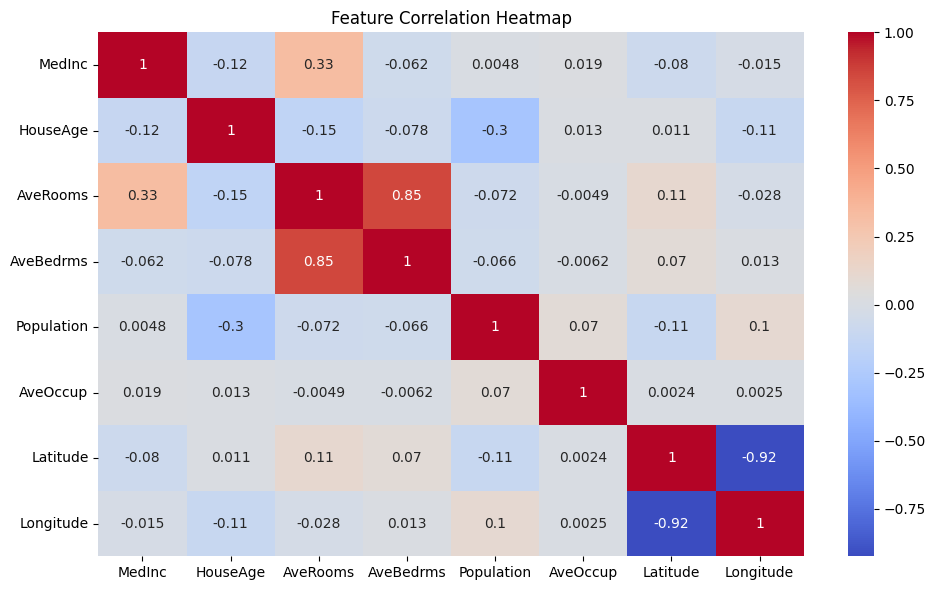

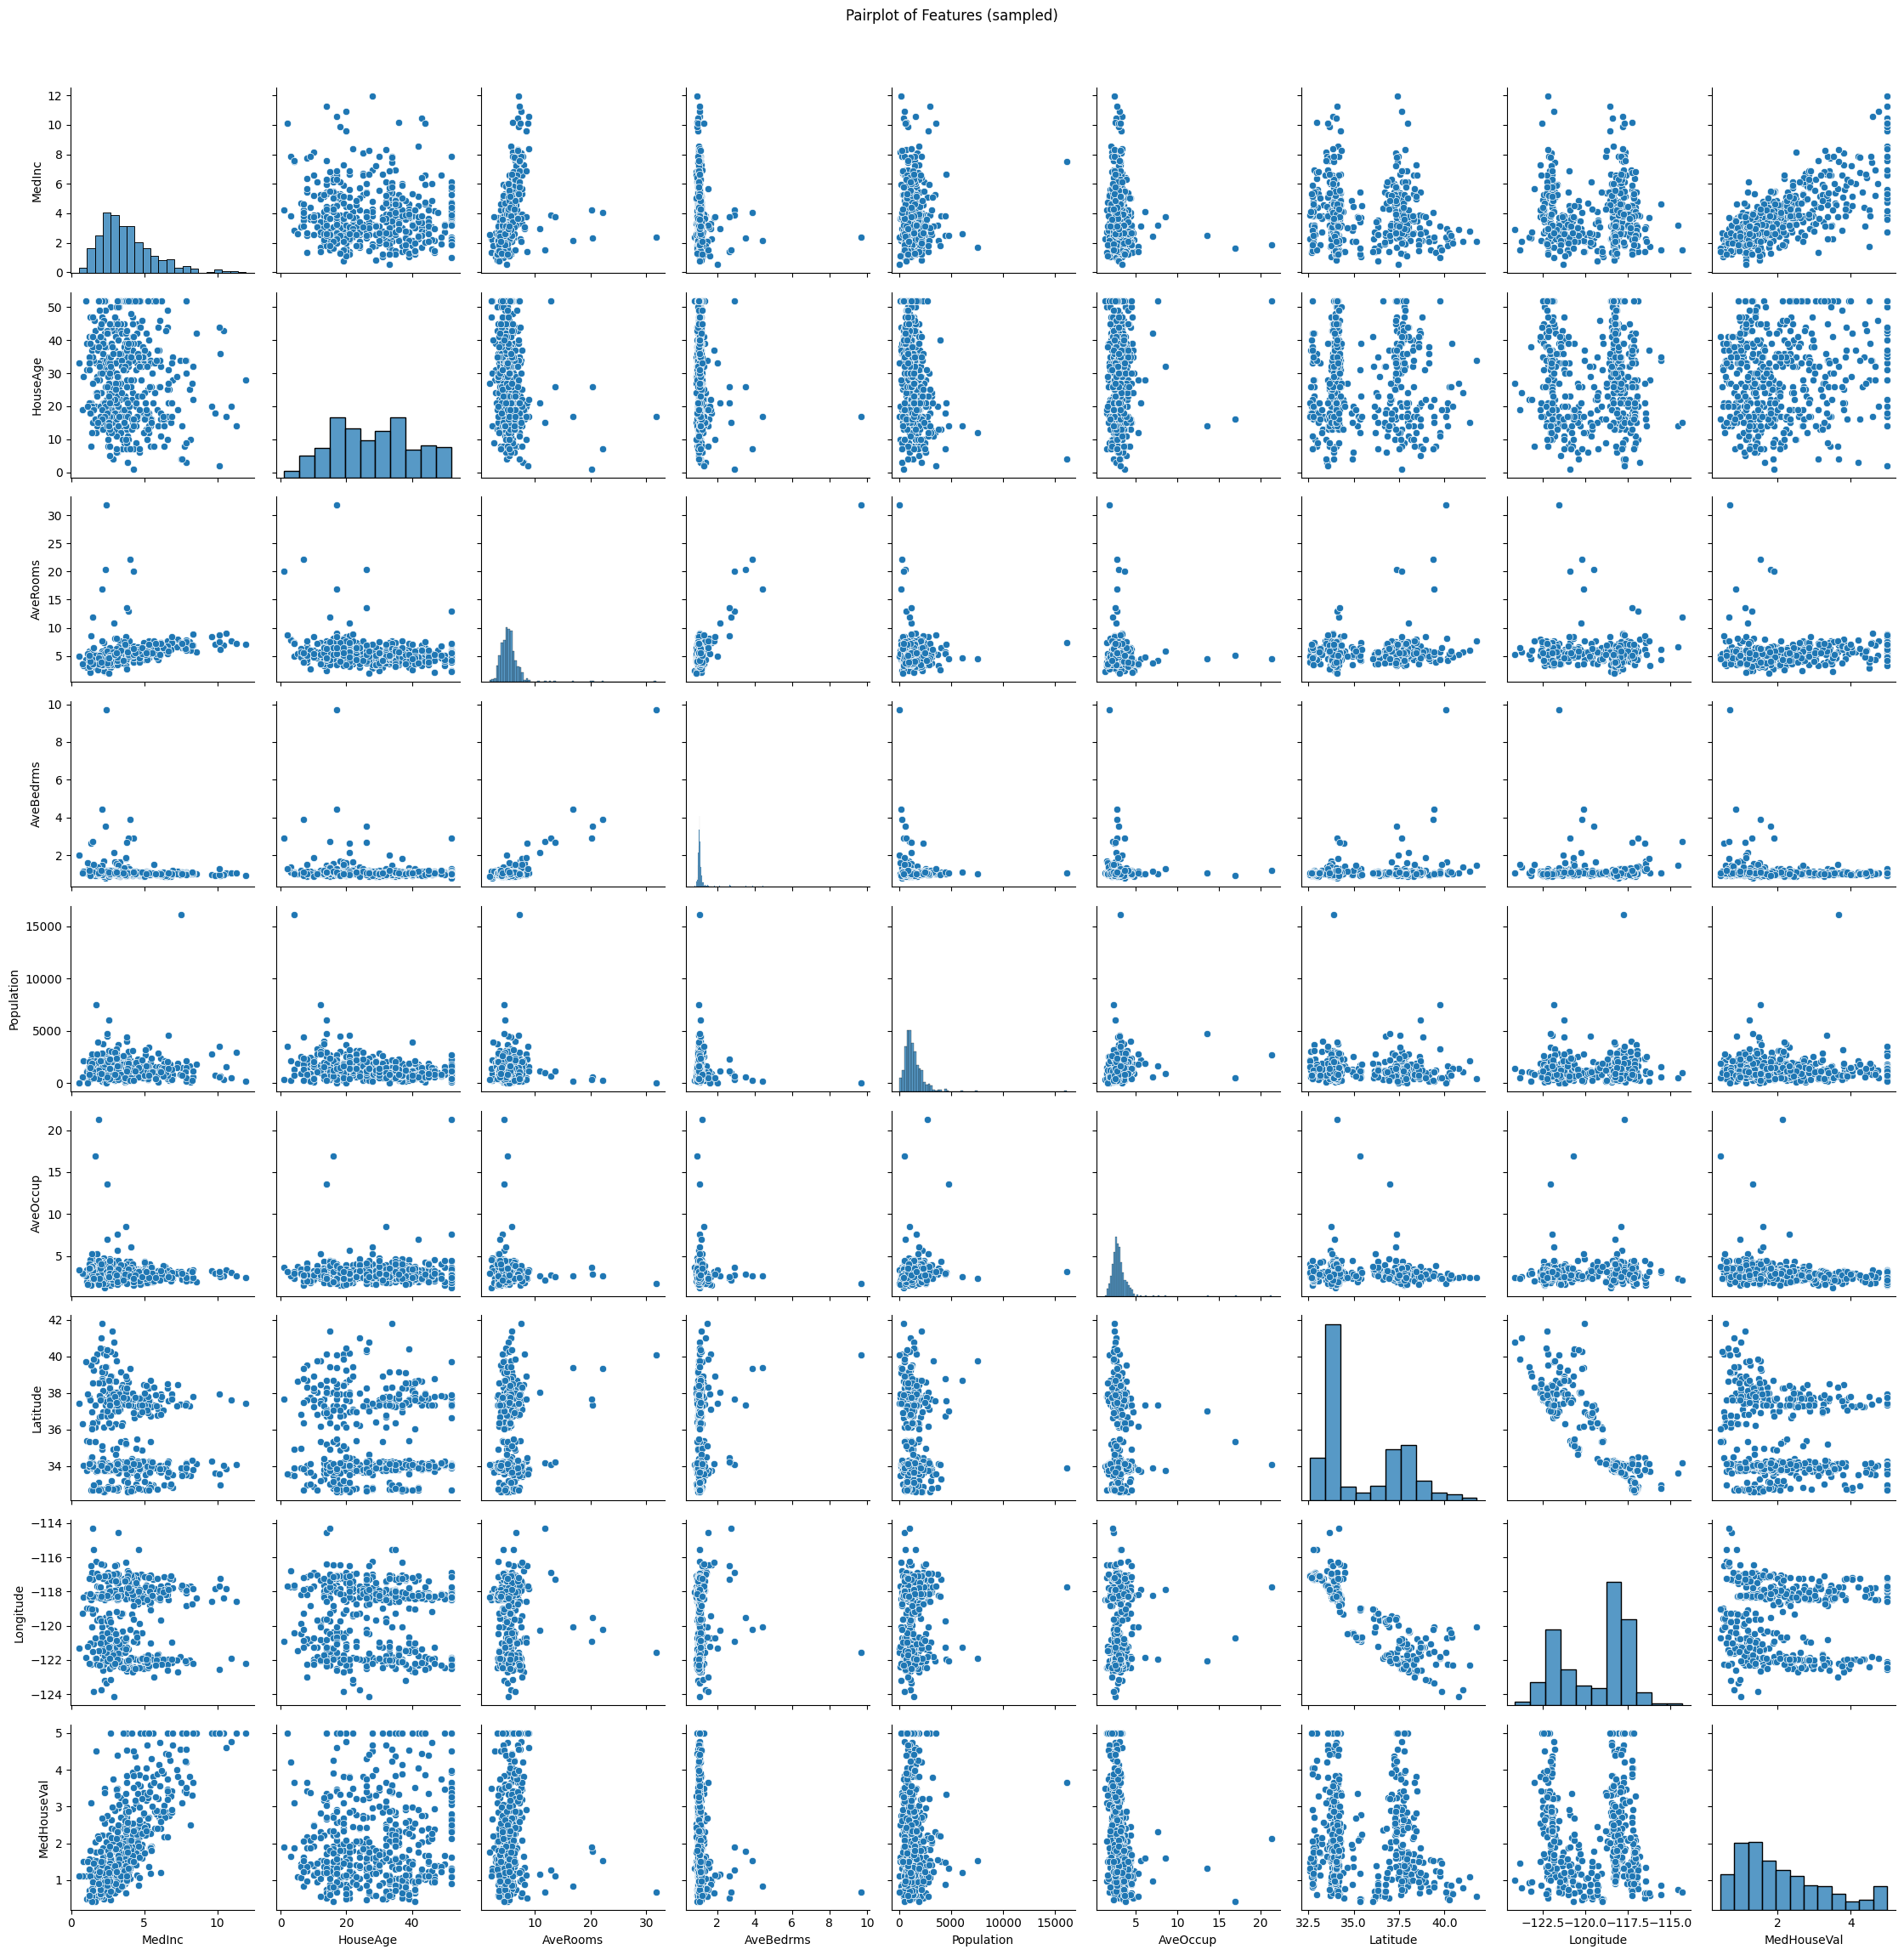

In [ ]:
# Step 2: Load the California Housing dataset
data = fetch_california_housing(as_frame=True)
# data = pd.read_csv('california_housing_train.csv')

# X: Features (all input variables), y: target (median house value)
X = data.data
y = data.target

# X = data.data.copy()
# y = data.target.copy()

# # ------------------- STEP 3: Feature Engineering -------------------
# X["RoomsPerPerson"] = X["AveRooms"] / (X["Population"] + 1)
# X["BedPerRoom"] = X["AveBedrms"] / (X["AveRooms"] + 1)
# X["MedInc_HouseAge"] = X["MedInc"] * X["HouseAge"]
# X["log_Population"] = np.log1p(X["Population"])
# X["sqrt_MedInc"] = np.sqrt(X["MedInc"])
# X.drop(columns=["AveBedrms"], inplace=True)
# X["HouseAgeGroup"] = pd.cut(X["HouseAge"], bins=[0, 10, 30, 52], labels=["New", "Mid", "Old"])
# X = pd.get_dummies(X, columns=["HouseAgeGroup"], drop_first=True)
# kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
# X["GeoCluster"] = kmeans.fit_predict(X[["Latitude", "Longitude"]])
# X = pd.get_dummies(X, columns=["GeoCluster"], drop_first=True)
# Step 3: Basic data checks
print("Feature names:", data.feature_names)
print("Shape of features and target:", X.shape, y.shape)
print("\nFirst 5 rows of feature data:\n", X.head())
print("\nFirst 5 rows of target values:\n", y.head())
print("\nSummary statistics of features:\n", X.describe())
print("\nCorrelation matrix:\n", X.corr())
print("\nNumber of missing values in each column:\n", X.isnull().sum())
print("\nInfo:")
X.info()

# Step 4: Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Step 5: Pairplot - WARNING: This may be slow and resource-intensive
# You can sample for faster plots
sampled_data = X.copy()
sampled_data['MedHouseVal'] = y
sns.pairplot(sampled_data.sample(500))  # Sample 500 for clarity/speed
plt.suptitle("Pairplot of Features (sampled)", y=1.02)
plt.tight_layout()
plt.show()

Step 2: Load the Dataset & Split Data

Why this split?
- We use a test set only at the end to evaluate generalization.
- Validation set is used during training to tune hyperparameters (like degree, lambda).

Why Scaling?
- Polynomial features tend to amplify differences; unscaled features would distort model fitting. StandardScaler ensures all features contribute equally.
- Polynomial and Ridge regression are sensitive to feature magnitudes.

- Standardization improves convergence during optimization.

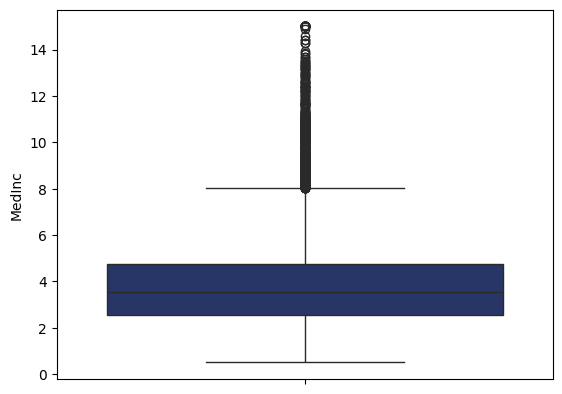

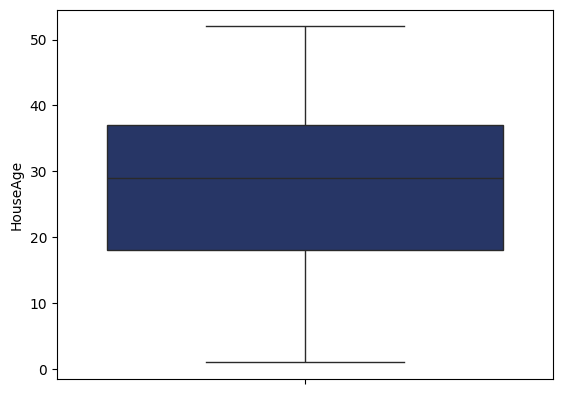

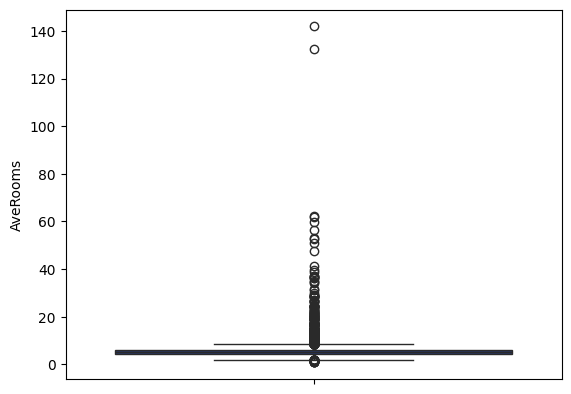

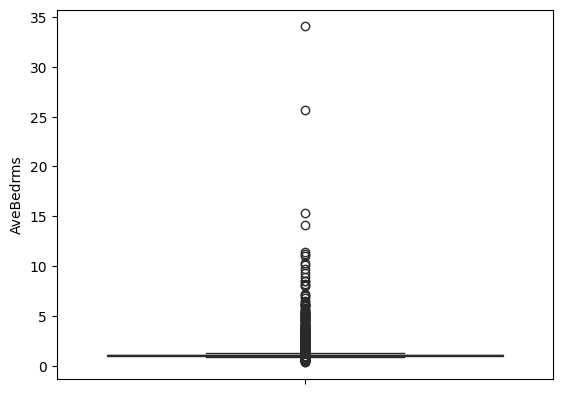

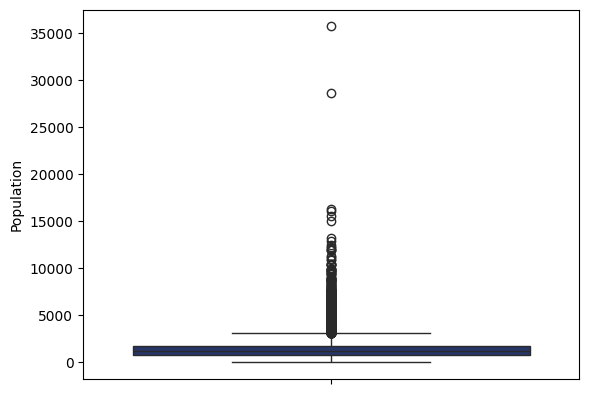

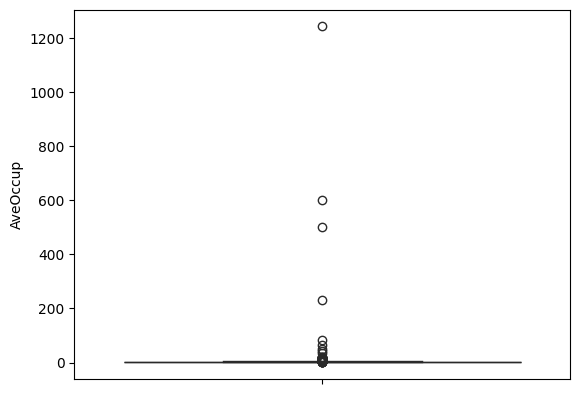

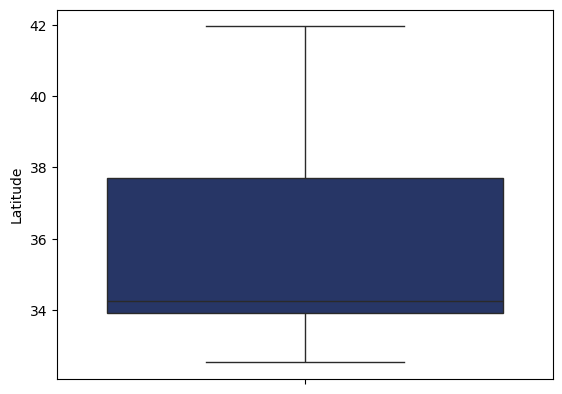

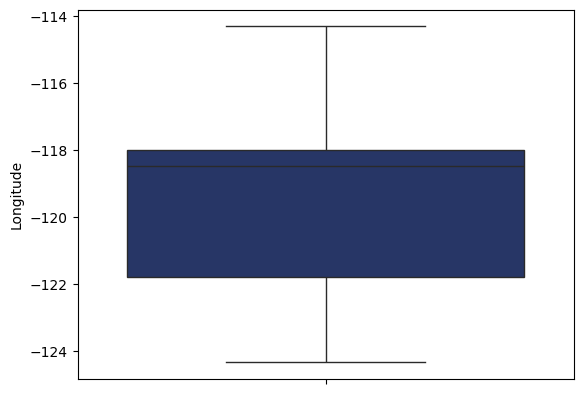

In [ ]:
# Boxplot for the all the columns to check the outliers
# print(data.)
columns_list = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
for i in columns_list:
  sns.boxplot(y=i,data=X,color='#1D3070')
  plt.show()

In [ ]:
df_copy = X.copy()

In [ ]:
df_copy1 = df_copy.copy()
from scipy import stats
delet_outliers = df_copy1[(np.abs(stats.zscore(df_copy1.iloc[:,:])) < 3).all(axis=1)]
print(df_copy1.shape)
print(delet_outliers.shape)
sum_deliting_outliers = np.prod(delet_outliers.shape)
sum_original_data = np.prod(df_copy1.shape)
percent_losing_data = round(100*(sum_original_data-sum_deliting_outliers)/sum_original_data,2)
print(f'the percentage of losing data is: {percent_losing_data}%')

(20640, 8)
(19794, 8)
the percentage of losing data is: 4.1%


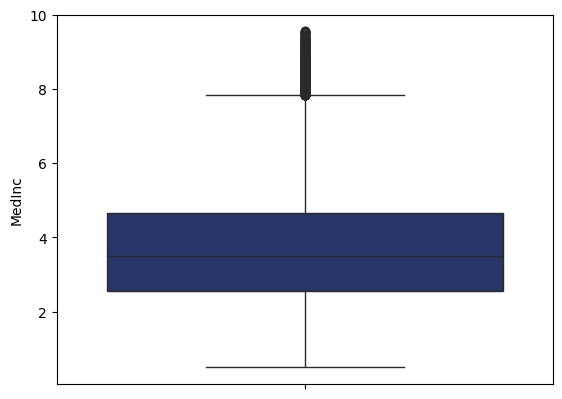

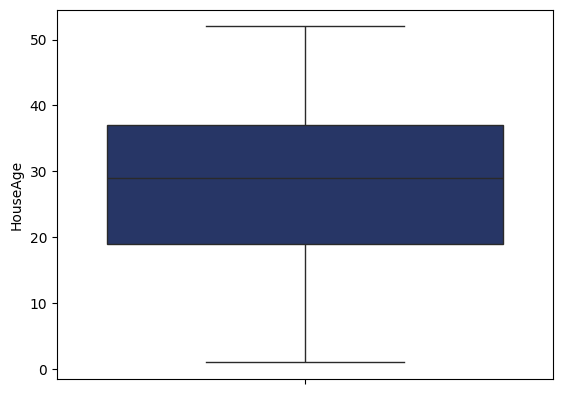

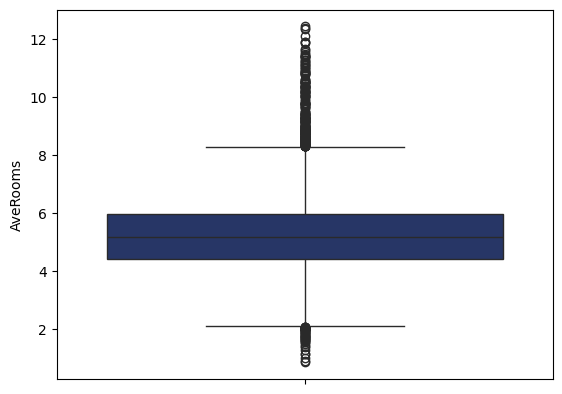

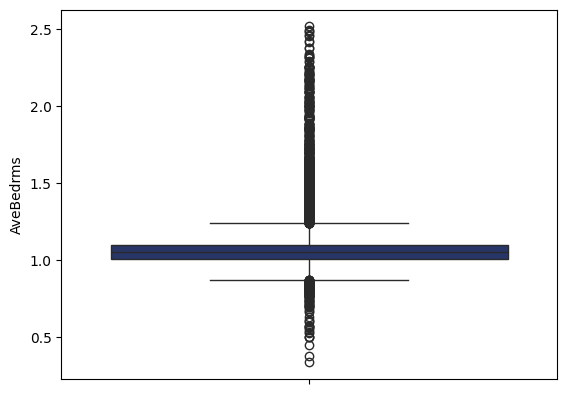

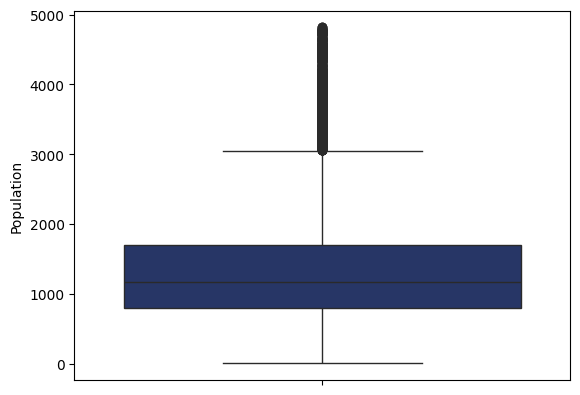

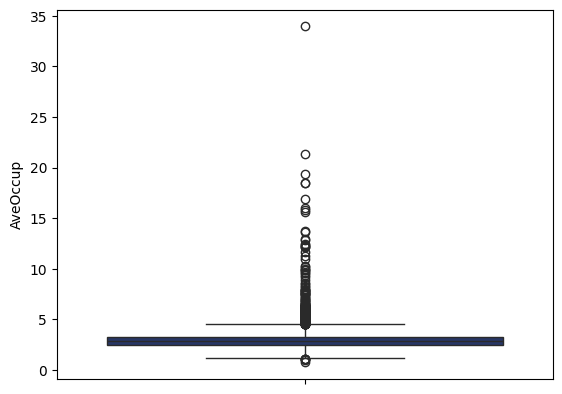

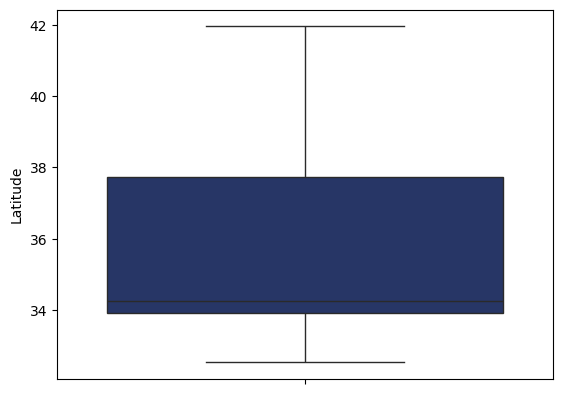

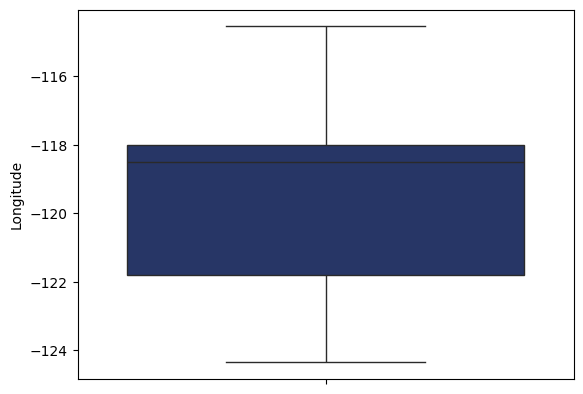

In [ ]:
columns_list = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
for i in columns_list:
  sns.boxplot(y=i,data=delet_outliers,color='#1D3070')
  plt.show()

In [ ]:
# First Split: Train (80%) and Test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Second Split: Train (80% of train_full) and Validation (20% of train_full)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# Standard Scaling (mean=0, std=1): It is important for polynomial and regularization methods
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Step 3: Define Ridge Regression with Polynomial Features

In [ ]:
# Define a function to train Ridge regression with Polynomial Features
def train_polynomial_ridge(X_train, y_train, X_val, y_val, degree, alpha, epochs=250):
    poly = PolynomialFeatures(degree=degree,include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    model = Ridge(alpha=alpha, fit_intercept=False, max_iter=epochs)

    train_sse = []
    val_sse = []

    # Manual training loop for SSE tracking
    for epoch in range(epochs):
        model.fit(X_train_poly, y_train)

        # Predictions
        y_train_pred = model.predict(X_train_poly)
        y_val_pred = model.predict(X_val_poly)

        # Calculate SSE (Sum of Squared Errors)
        train_sse.append(np.sum((y_train - y_train_pred) ** 2))
        val_sse.append(np.sum((y_val - y_val_pred) ** 2))

    return model, poly, train_sse, val_sse

# def train_polynomial_ridge(X_train, y_train, X_val, y_val, degree, alpha):
#     poly = PolynomialFeatures(degree=degree, include_bias=False)
#     X_train_poly = poly.fit_transform(X_train)
#     X_val_poly = poly.transform(X_val)

#     model = Ridge(alpha=alpha, fit_intercept=False)
#     model.fit(X_train_poly, y_train)

#     # Predictions
#     y_train_pred = model.predict(X_train_poly)
#     y_val_pred = model.predict(X_val_poly)

#     # SSE (no epochs)
#     train_sse = np.sum((y_train - y_train_pred) ** 2)
#     val_sse = np.sum((y_val - y_val_pred) ** 2)

#     return model, poly, train_sse, val_sse


Step 4: Train for Various Degrees and Lambda Values

In [ ]:
# Define parameter combinations
degrees = [2, 3, 5]
# degrees = [2]
# lambdas = [1e-5, 1e-3, 1e-1]
lambdas = [0, 0.01, 0.1, 1, 10, 100]
# ridge 0 : Means linear regression
results = []
loss_history = {}

for deg in degrees:
    for lam in lambdas:
        model, poly, train_loss, val_loss = train_polynomial_ridge(
            X_train, y_train, X_val, y_val, degree=deg, alpha=lam
        )

        X_train_poly = poly.transform(X_train)
        X_val_poly = poly.transform(X_val)
        y_train_pred = model.predict(X_train_poly)
        y_val_pred = model.predict(X_val_poly)

        results.append({
            'degree': deg,
            'lambda': lam,
            'model': model,
            'poly': poly,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'r2_train': r2_score(y_train, y_train_pred),
            'r2_val': r2_score(y_val, y_val_pred),
            'train_sse': train_loss[-1],
            'val_sse': val_loss[-1],
        })

        loss_history[(deg, lam)] = (train_loss, val_loss)
        print(f"Trained degree={deg}, lambda={lam}")

# for deg in degrees:
#     for lam in lambdas:
#         model, poly, train_sse, val_sse = train_polynomial_ridge(
#             X_train, y_train, X_val, y_val, degree=deg, alpha=lam
#         )

#         X_train_poly = poly.transform(X_train)
#         X_val_poly = poly.transform(X_val)
#         y_train_pred = model.predict(X_train_poly)
#         y_val_pred = model.predict(X_val_poly)

#         results.append({
#             'degree': deg,
#             'lambda': lam,
#             'model': model,
#             'poly': poly,
#             'r2_train': r2_score(y_train, y_train_pred),
#             'r2_val': r2_score(y_val, y_val_pred),
#             'train_sse': train_sse,
#             'val_sse': val_sse,
#         })
#         loss_history[(deg, lam)] = (train_loss, val_loss)
#         print(f"Trained degree={deg}, lambda={lam}")


Trained degree=2, lambda=0
Trained degree=2, lambda=0.01
Trained degree=2, lambda=0.1
Trained degree=2, lambda=1
Trained degree=2, lambda=10
Trained degree=2, lambda=100


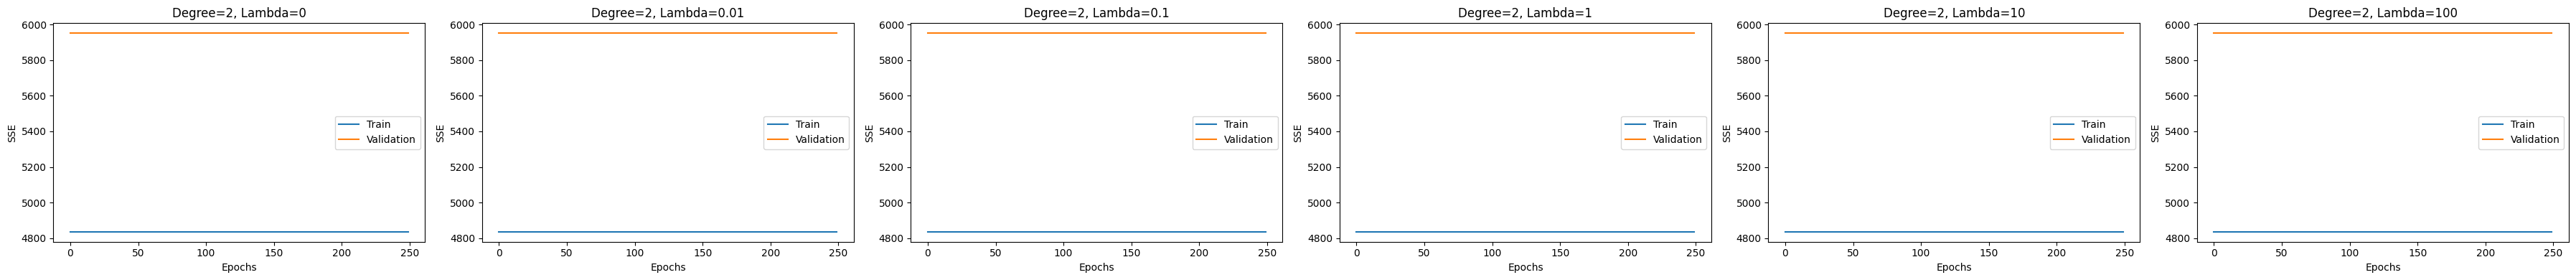

In [ ]:
# # --- Step 5: Plot Loss vs Epoch ---
fig, axs = plt.subplots(len(degrees), len(lambdas), figsize=(6 * len(lambdas), 4 * len(degrees)), squeeze=False)

for i, deg in enumerate(degrees):
    for j, lam in enumerate(lambdas):
        train_loss, val_loss = loss_history[(deg, lam)]
        ax = axs[i][j]  # safe access as 2D array
        ax.plot(train_loss, label='Train')
        ax.plot(val_loss, label='Validation')
        ax.set_title(f'Degree={deg}, Lambda={lam}')
        ax.set_xlabel('Epochs')
        ax.set_ylabel('SSE')
        ax.legend()

plt.tight_layout()
plt.show()


Why Polynomial Regression?
- Captures non-linear trends in data.

Why L2 Regularization (Ridge)?
- Penalizes large weights to prevent overfitting due to complex polynomial features.

Why Epochs?
- Simulated here just to track loss progression, although Ridge solves it analytically.

Use these curves to visually choose the best polynomial degree and lambda where:

Validation loss is low

Train & Val loss don’t diverge (indicating no overfitting)

Step 5: Predict on Test Set with Top-3 Models

In [ ]:
# --- Step 6: Evaluate Top-3 Models ---
top_models = sorted(results, key=lambda r: r['val_sse'])[:3]

for idx, res in enumerate(top_models, 1):
    model = res['model']
    poly = res['poly']

    X_train_poly = poly.transform(X_train)
    X_val_poly = poly.transform(X_val)
    X_test_poly = poly.transform(X_test)

    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_val_poly)
    y_test_pred = model.predict(X_test_poly)

    sse_train = np.sum((y_train - y_train_pred)**2)
    sse_val = np.sum((y_val - y_val_pred)**2)
    sse_test = np.sum((y_test - y_test_pred)**2)

    r2_train = r2_score(y_train, y_train_pred)
    r2_val = r2_score(y_val, y_val_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print(f"\nTop-{idx} Model: Degree={res['degree']}, Lambda={res['lambda']}")
    print(f"  SSE Train: {sse_train:.4f}, R² Train: {r2_train:.4f}")
    print(f"  SSE Val  : {sse_val:.4f}, R² Val  : {r2_val:.4f}")
    print(f"  SSE Test : {sse_test:.4f}, R² Test : {r2_test:.4f}")



Top-1 Model: Degree=2, Lambda=100
  SSE Train: 4836.0258, R² Train: 0.7239
  SSE Val  : 5951.2208, R² Val  : -0.3056
  SSE Test : 1715.9175, R² Test : 0.6828

Top-2 Model: Degree=2, Lambda=10
  SSE Train: 4571.8592, R² Train: 0.7389
  SSE Val  : 111706.7458, R² Val  : -23.5073
  SSE Test : 1664.5163, R² Test : 0.6923

Top-3 Model: Degree=2, Lambda=1
  SSE Train: 4502.5506, R² Train: 0.7429
  SSE Val  : 344455.0737, R² Val  : -74.5699
  SSE Test : 1651.2197, R² Test : 0.6947


Step 6: Print Final Metrics for Top-3 Models

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Define hyperparameters to try
n_estimators_list = [100, 200]
max_depth_list = [10, 20, None]

results_rf = []

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        rf = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)

        # Predict
        y_train_pred = rf.predict(X_train)
        y_val_pred = rf.predict(X_val)
        y_test_pred = rf.predict(X_test)

        # SSE = MSE * n_samples
        train_sse = mean_squared_error(y_train, y_train_pred) * len(y_train)
        val_sse = mean_squared_error(y_val, y_val_pred) * len(y_val)
        test_sse = mean_squared_error(y_test, y_test_pred) * len(y_test)

        # R² Score
        r2_train = r2_score(y_train, y_train_pred)
        r2_val = r2_score(y_val, y_val_pred)
        r2_test = r2_score(y_test, y_test_pred)

        results_rf.append({
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "train_sse": train_sse,
            "val_sse": val_sse,
            "test_sse": test_sse,
            "r2_train": r2_train,
            "r2_val": r2_val,
            "r2_test": r2_test,
            "model": rf
        })

        print(f"Trained RF: n_estimators={n_estimators}, max_depth={max_depth}")


Trained RF: n_estimators=100, max_depth=10
Trained RF: n_estimators=100, max_depth=20
Trained RF: n_estimators=100, max_depth=None
Trained RF: n_estimators=200, max_depth=10
Trained RF: n_estimators=200, max_depth=20
Trained RF: n_estimators=200, max_depth=None


In [ ]:
# Sort models by validation SSE (ascending)
top_rf_models = sorted(results_rf, key=lambda x: x['val_sse'])[:3]

# Display results
for i, m in enumerate(top_rf_models, 1):
    print(f"\nTop-{i} Random Forest Model: n_estimators={m['n_estimators']}, max_depth={m['max_depth']}")
    print(f"  SSE Train: {m['train_sse']:.4f}, R² Train: {m['r2_train']:.4f}")
    print(f"  SSE Val  : {m['val_sse']:.4f}, R² Val  : {m['r2_val']:.4f}")
    print(f"  SSE Test : {m['test_sse']:.4f}, R² Test : {m['r2_test']:.4f}")



Top-1 Random Forest Model: n_estimators=200, max_depth=20
  SSE Train: 489.0173, R² Train: 0.9721
  SSE Val  : 893.3184, R² Val  : 0.8040
  SSE Test : 1070.4010, R² Test : 0.8021

Top-2 Random Forest Model: n_estimators=100, max_depth=20
  SSE Train: 497.6339, R² Train: 0.9716
  SSE Val  : 895.4225, R² Val  : 0.8036
  SSE Test : 1077.7799, R² Test : 0.8008

Top-3 Random Forest Model: n_estimators=200, max_depth=None
  SSE Train: 462.1466, R² Train: 0.9736
  SSE Val  : 897.1494, R² Val  : 0.8032
  SSE Test : 1069.0446, R² Test : 0.8024


Random Forest captures non-linearities and feature interactions without requiring manual polynomial transformations.

Even with just basic hyperparameter tuning (n_estimators and max_depth), you're achieving R² scores above 0.80, which is a strong fit.

The small gap between train and validation R² (0.9721 vs 0.8040) shows mild overfitting, but the generalization is still good.

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print("Cross-Validation R² Scores:", scores)
print("Mean:", scores.mean(), "Std Dev:", scores.std())

Cross-Validation R² Scores: [-2.60215044 -2.58003289 -2.62072304 -2.53634242 -2.76729342]
Mean: -2.621308441522042 Std Dev: 0.07823283291342245


**Problem: COVID-19 Exponential Growth Modeling (March–May 2020, India)**

We are assuming that COVID-19 new cases followed an exponential growth:

𝑦
=
𝐴
⋅
𝑒
𝐵
𝑥
y=A⋅e
Bx

Taking the log:

ln
⁡
(
𝑦
)
=
ln
⁡
(
𝐴
)
+
𝐵
𝑥
⇒
Linear in form
ln(y)=ln(A)+Bx⇒Linear in form
So we can fit Linear Regression on:

x: days since March 1, 2020

log(y): log of new_cases

Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


Step 2: Load COVID Data for India (OWID)

In [ ]:
url = 'https://covid.ourworldindata.org/data/owid-covid-data.csv'
df = pd.read_csv(url)

print("Feature names:", df.columns)
print("Shape of data:", df.shape)
print("\nFirst 5 rows of data values:\n", df.head())
print("\nSummary statistics of features:\n", df.describe())
print("\nInfo:")
df.info()
# print("\nCorrelation matrix:\n", df.corr())
print("\nNumber of missing values in each column:\n", df.isnull().sum())

Feature names: Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoot

In [ ]:

# Filter for India and date range
df_india = df[df['location'] == 'India'].copy()
df_india['date'] = pd.to_datetime(df_india['date'])
mask = (df_india['date'] >= '2020-03-01') & (df_india['date'] <= '2020-05-31')
df_period = df_india[mask].copy()


Step 3: Prepare x (days) and y (new cases)

In [ ]:
# x: Day number from March 1, 2020
df_period['days_since_start'] = (df_period['date'] - pd.Timestamp('2020-03-01')).dt.days

# y: new_cases, fill missing with 0 and avoid log(0)
df_period['new_cases'] = df_period['new_cases'].fillna(0)
df_period['new_cases'] = df_period['new_cases'].apply(lambda x: x if x > 0 else 1)

# log_y = ln(new_cases)
df_period['log_new_cases'] = np.log(df_period['new_cases'])


Step 4: Fit Linear Regression on (x, log(y))

In [ ]:
X = df_period['days_since_start'].values.reshape(-1, 1)
y_log = df_period['log_new_cases'].values

model = LinearRegression()
model.fit(X, y_log)

y_log_pred = model.predict(X)


Step 5: Plot Actual vs Predicted (log scale)
python
Copy code


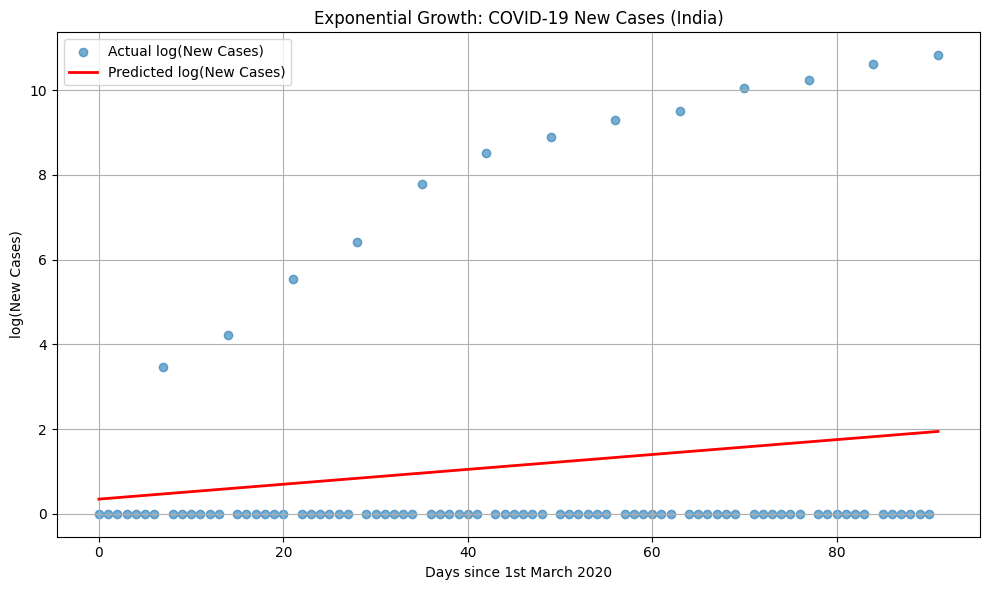

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y_log, label='Actual log(New Cases)', alpha=0.6)
plt.plot(X, y_log_pred, color='red', label='Predicted log(New Cases)', linewidth=2)
plt.xlabel("Days since 1st March 2020")
plt.ylabel("log(New Cases)")
plt.title("Exponential Growth: COVID-19 New Cases (India)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Step 6: Print SSE (Sum of Squared Errors)

In [ ]:
sse = np.sum((y_log - y_log_pred) ** 2)
print(f"SSE (log scale) between actual and predicted: {sse:.4f}")


SSE (log scale) between actual and predicted: 785.6762
